<a href="https://colab.research.google.com/github/raja6294/Data_Analytics/blob/main/BCT.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
import pandas as pd
import json


try:

    with open('/content/raw_posts.json', 'r', encoding='utf-8', errors='ignore') as f:
        json_content = f.read()


    data = json.loads(json_content)
    df = pd.DataFrame(data)
except json.JSONDecodeError:
    data = []
    with open('/content/raw_posts.json', 'r', encoding='utf-8', errors='ignore') as f:
        for line in f:
            try:
                data.append(json.loads(line))
            except json.JSONDecodeError:
                continue
    df = pd.DataFrame(data)
except Exception as e:
    print(f"An unexpected error occurred: {e}")
    raise


print("Dataset Preview:")
print(df.head())
df['Platform'] = df['text'].apply(lambda x: 'LinkedIn' if 'LinkedIn' in str(x) else 'Other')

result = df.groupby('Platform')['engagement'].sum().reset_index()
result.rename(columns={'engagement': 'Total Engagement'}, inplace=True)

print("\nTotal Engagement per Platform:")
print(result)

if not result.empty:
    max_engagement_platform = result.loc[result['Total Engagement'].idxmax()]
    print("\nPlatform with Highest Engagement:", max_engagement_platform['Platform'], "(", max_engagement_platform['Total Engagement'], "total engagement )")
else:
    print("\nNo engagement data available for analysis.")


Dataset Preview:
                                                text  engagement
0  Just saw a LinkedIn Influencer with 'Organic G...          90
1  Jobseekers, this one’s for you.\n Every applic...         347
2  Looking for jobs on LinkedIn is like online da...         109
3  LinkedIn scams be like: 'Congratulations, you'...         115
4  sapne dekhna achi baat hai,\nlekin job ka sapn...         545

Total Engagement per Platform:
   Platform  Total Engagement
0  LinkedIn              2102
1     Other             23136

Platform with Highest Engagement: Other ( 23136 total engagement )


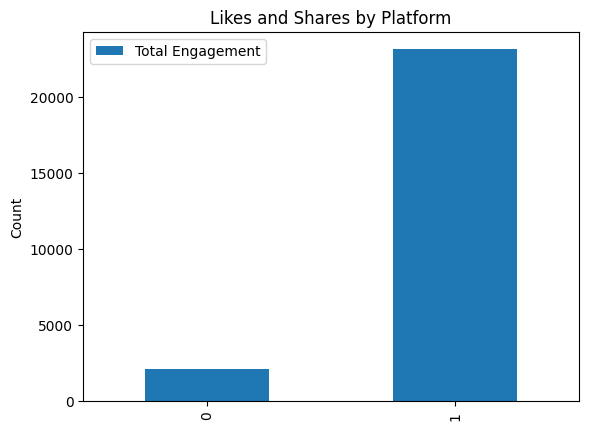

In [ ]:
import matplotlib.pyplot as plt

result.plot(kind='bar')
plt.title("Likes and Shares by Platform")
plt.ylabel("Count")
plt.show()

In [11]:
import seaborn as sns
import pandas as pd

# Load the Titanic dataset
titanic_df = sns.load_dataset('titanic')

# Display the first 5 rows of the DataFrame
print("Titanic Dataset Preview:")
display(titanic_df.head())
survival_rate_by_class = titanic_df.groupby('class')['survived'].mean()

Titanic Dataset Preview:


,survived,pclass,sex,age,sibsp,parch,fare,embarked,class,who,adult_male,deck,embark_town,alive,alone
0,0,3,male,22.0,1,0,7.2500,S,Third,man,True,NaN,Southampton,no,False
1,1,1,female,38.0,1,0,71.2833,C,First,woman,False,C,Cherbourg,yes,False
2,1,3,female,26.0,0,0,7.9250,S,Third,woman,False,NaN,Southampton,yes,True
3,1,1,female,35.0,1,0,53.1000,S,First,woman,False,C,Southampton,yes,False
4,0,3,male,35.0,0,0,8.0500,S,Third,man,True,NaN,Southampton,no,True


/tmp/ipykernel_4222/692467435.py:10: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  survival_rate_by_class = titanic_df.groupby('class')['survived'].mean()


In [14]:
sorted_age = titanic_df.sort_values("age")
print(sorted_age.head())

     survived  pclass     sex   age  sibsp  parch     fare embarked   class  \
803         1       3    male  0.42      0      1   8.5167        C   Third   
755         1       2    male  0.67      1      1  14.5000        S  Second   
644         1       3  female  0.75      2      1  19.2583        C   Third   
469         1       3  female  0.75      2      1  19.2583        C   Third   
78          1       2    male  0.83      0      2  29.0000        S  Second   

       who  adult_male deck  embark_town alive  alone  
803  child       False  NaN    Cherbourg   yes  False  
755  child       False  NaN  Southampton   yes  False  
644  child       False  NaN    Cherbourg   yes  False  
469  child       False  NaN    Cherbourg   yes  False  
78   child       False  NaN  Southampton   yes  False  
